# 🔎 Notebook 08 — Model Interpretation

## 🎯 Objective
Explain and diagnose the trained heart-disease prediction model using multiple, complementary
interpretability tools. We aim to understand **which features drive predictions** and **how**.

## 🧰 Methods Covered
- **Global importance**: model coefficients (LogReg), Gini importances (RF/XGB), permutation importance
- **Response shape**: Partial Dependence Plots (PDP) & ICE curves
- **Local + global explanations**: SHAP summary (global) and force/waterfall (local)

## 📥 Inputs
- Best model pipeline from `models/heart_model_<run_id>.pkl` (selected in Notebook 07 or 05)
- Processed test set from `data/processed/`
- (Optional) `src/features.py:get_feature_names` to recover transformed feature names

## 📦 Outputs
- `reports/feature_importances_<run_id>.png`
- `reports/permutation_importance_<run_id>.png`
- `reports/pdp_<feature>_<run_id>.png`
- `reports/shap_summary_<run_id>.png`
- `reports/shap_topk_locals_<run_id>.png`

> These artifacts support model review, debugging, and responsible deployment.


In [2]:
# (Colab only) mount & cd
IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction



Mounted at /content/drive
/content/drive/MyDrive/Dr. Taiwo famuyiwa - Data Science & Biostatistics Portfolio/Machine Learning Projects/Heart-Disease-Prediction


In [3]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
sys.path.append(os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from src.data import PROC_DIR
from src.features import build_preprocessor  # and optionally get_feature_names if you added it

REPORTS_DIR = Path("reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR  = Path("models")

In [4]:
# Data
X_test = pd.read_csv(PROC_DIR / "X_test.csv")
y_test = pd.read_csv(PROC_DIR / "y_test.csv").squeeze("columns")

# Best model pointer (written in 05/07)
best_meta_path = REPORTS_DIR / "best_model.json"
if best_meta_path.exists():
    best_meta = json.loads(best_meta_path.read_text())
    run_id = best_meta["best_run_id"]
    model_path = MODELS_DIR / f"heart_model_{run_id}.pkl"
else:
    # fallback: newest artifact
    candidates = sorted(MODELS_DIR.glob("heart_model_*.pkl"), key=lambda p: p.stat().st_mtime, reverse=True)
    assert candidates, "No model artifacts found."
    model_path = candidates[0]
    run_id = model_path.stem.replace("heart_model_", "(unknown-run)")

print("Loading:", model_path.name)

import joblib
pipe = joblib.load(model_path)

# quick sanity: test-set metrics
proba = pipe.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 3),
      "| AP:", round(average_precision_score(y_test, proba), 3))


Loading: heart_model_logreg_tuned_seed42_1761367619.pkl
Test ROC-AUC: 0.908 | AP: 0.873


## 2) Recover final feature names

In [5]:
# Try project helper first (if you created it)
feat_names = None
try:
    from src.features import get_feature_names  # your version that matches your pipeline
    # You must pass the same lists you used when building preprocessor in src.features
    NUM_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    CAT_COLS = ["sex", "fbs", "exang", "restecg", "slope", "ca", "thal", "cp"]
    ENGINEERED_NUM = ["hr_reserve","bp_per_age","chol_per_age"]
    ENGINEERED_CAT = ["age_bin"]
    feat_names = get_feature_names(
        preproc=pipe.named_steps.get("pre", pipe.named_steps.get("preprocess", pipe)),
        num_cols=NUM_COLS, cat_cols=CAT_COLS,
        engineered_num=ENGINEERED_NUM, engineered_cat=ENGINEERED_CAT
    )
except Exception as e:
    print("Feature-name helper not available or failed:", e)

# Defensive fallback: if names not available, use index labels
if feat_names is None:
    # transform once to know dimensionality
    try:
        X_trans = pipe.named_steps["pre"].transform(X_test)
    except Exception:
        # pipeline may be just (pre, model); otherwise transform X_test directly
        try:
            X_trans = pipe.transform(X_test)
        except Exception:
            X_trans = None
    if X_trans is not None:
        feat_names = [f"f_{i}" for i in range(X_trans.shape[1])]
    else:
        feat_names = []  # will handle later if needed

len(feat_names), feat_names[:10]


(36,
 ['age',
  'trestbps',
  'chol',
  'thalach',
  'oldpeak',
  'hr_reserve',
  'bp_per_age',
  'chol_per_age',
  'sex_0.0',
  'sex_1.0'])

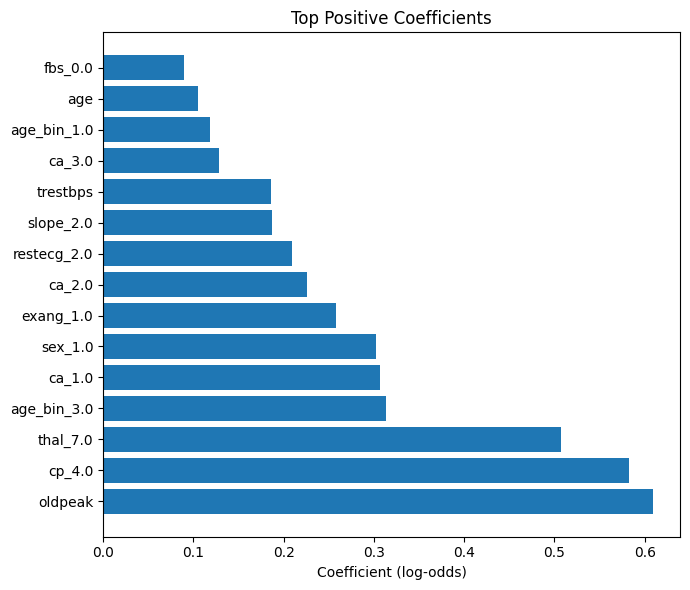

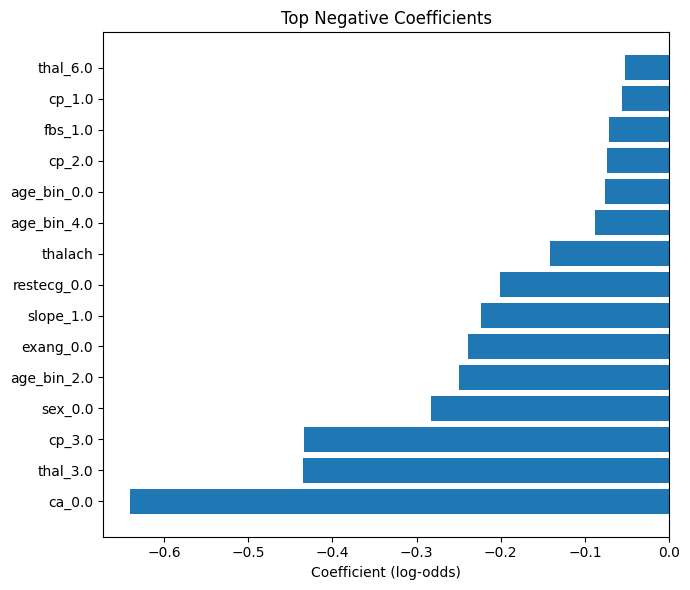

In [6]:
from sklearn.linear_model import LogisticRegression

final_est = pipe.named_steps.get("model", None)
if isinstance(final_est, LogisticRegression):
    coefs = final_est.coef_[0]
    order = np.argsort(coefs)
    topN = 15

    plt.figure(figsize=(7,6))
    idx = order[-topN:][::-1]
    labels = [feat_names[i] for i in idx] if feat_names else [str(i) for i in idx]
    plt.barh(range(topN), coefs[idx])
    plt.yticks(range(topN), labels)
    plt.xlabel("Coefficient (log-odds)")
    plt.title("Top Positive Coefficients")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"coefficients_pos_{run_id}.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7,6))
    idx = order[:topN]
    labels = [feat_names[i] for i in idx] if feat_names else [str(i) for i in idx]
    plt.barh(range(topN), coefs[idx])
    plt.yticks(range(topN), labels)
    plt.xlabel("Coefficient (log-odds)")
    plt.title("Top Negative Coefficients")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"coefficients_neg_{run_id}.png", bbox_inches="tight")
    plt.show()
else:
    print("Final estimator is not LogisticRegression; skipping coefficients view.")


## Permutation Importance (model-agnostic, robust)

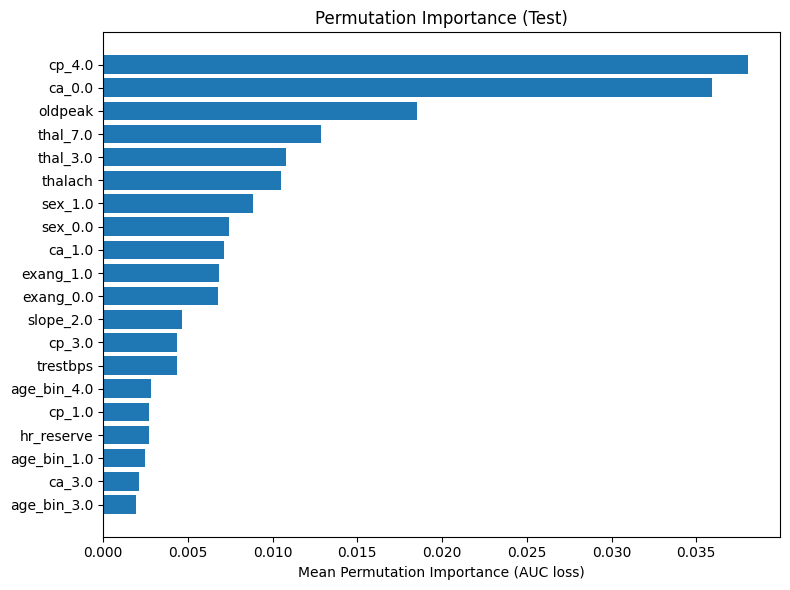

In [7]:
# Get transformed matrix to speed up permutation if needed
try:
    X_trans = pipe.named_steps["pre"].transform(X_test)
    est = pipe.named_steps["model"]
except Exception:
    # If pipeline is model-only (unlikely), fall back to the whole pipe
    X_trans = X_test
    est = pipe

# scoring on probabilities (AUC)
perm = permutation_importance(
    est, X_trans, y_test,
    n_repeats=20, random_state=42, scoring="roc_auc", n_jobs=-1
)
order = np.argsort(perm.importances_mean)[::-1]
topN = min(20, len(order))

plt.figure(figsize=(8,6))
idx = order[:topN]
labels = [feat_names[i] for i in idx] if feat_names and len(feat_names)==X_trans.shape[1] else [str(i) for i in idx]
plt.barh(range(topN), perm.importances_mean[idx])
plt.yticks(range(topN), labels)
plt.gca().invert_yaxis()
plt.xlabel("Mean Permutation Importance (AUC loss)")
plt.title("Permutation Importance (Test)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / f"permutation_importance_{run_id}.png", bbox_inches="tight")
plt.show()


## 5) Partial Depenced & ICE

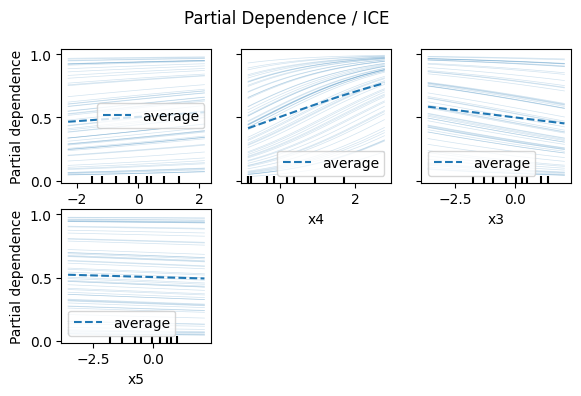

In [8]:
# Pick by name if available; otherwise choose indices from top importances
candidate_names = ["age", "oldpeak", "thalach", "cp", "ca", "hr_reserve"]
plot_names = [n for n in candidate_names if n in feat_names] if feat_names else []

# If we failed to map names, fall back to top 3 by permutation importance
if not plot_names and 'idx' in locals():
    plot_idx = idx[:3]
else:
    plot_idx = [feat_names.index(n) for n in plot_names]

# Plot PDP & ICE using the fitted estimator on transformed space
try:
    fig, ax = plt.subplots(figsize=(6,4))
    PartialDependenceDisplay.from_estimator(
        est, X_trans, plot_idx, kind="both", subsample=1000, ice_lines_kw={"alpha":0.2}, ax=ax
    )
    plt.suptitle("Partial Dependence / ICE")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"pdp_{run_id}.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("PDP/ICE failed (often due to feature indexing mismatch):", e)


## 6) SHAP (global summary + top-K locals)

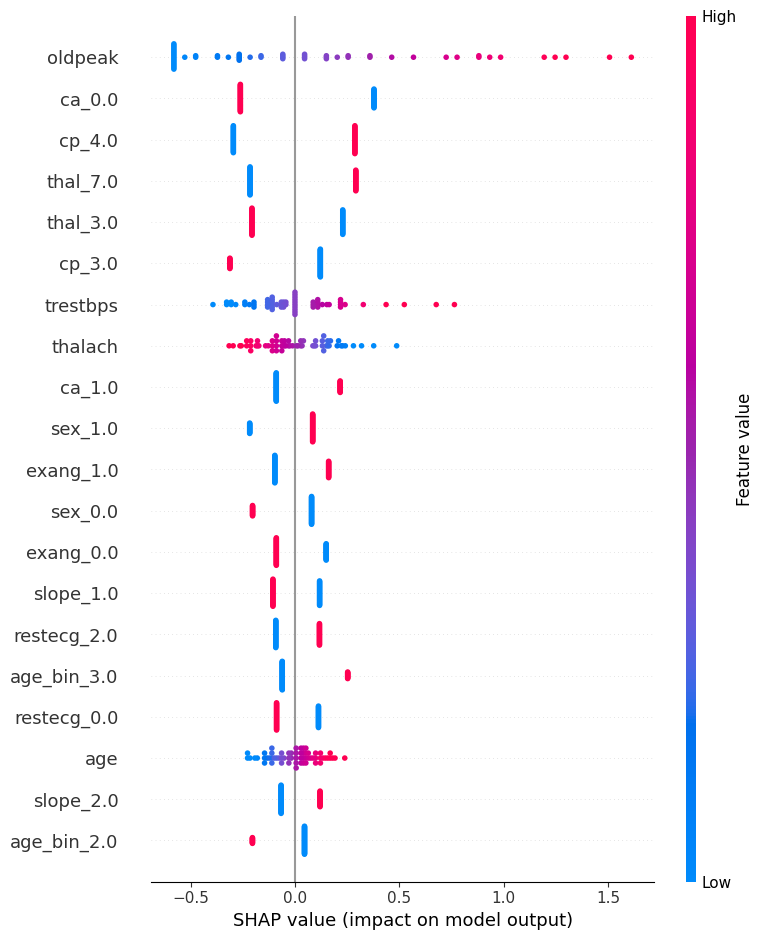

SHAP artifacts saved.


In [9]:
shap_ok = True
try:
    import shap
except Exception as e:
    shap_ok = False
    print("SHAP not installed:", e)

if shap_ok:
    try:
        # Choose background sample (speed)
        bgN = min(200, X_test.shape[0])
        # Transform X once for SHAP with final estimator
        X_trf = X_trans  # from earlier
        # Pick explainer
        from sklearn.ensemble import RandomForestClassifier
        is_tree = isinstance(final_est, RandomForestClassifier)
        try:
            from xgboost import XGBClassifier
            is_tree = is_tree or isinstance(final_est, XGBClassifier)
        except Exception:
            pass

        if is_tree:
            explainer = shap.TreeExplainer(final_est)
            sv = explainer.shap_values(X_trf)
            # For binary classification, take class-1 explanations
            shap_vals = sv[1] if isinstance(sv, list) and len(sv)==2 else sv
        else:
            # Fallback: linear or generic model
            explainer = shap.LinearExplainer(final_est, X_trf, feature_perturbation="interventional")
            shap_vals = explainer.shap_values(X_trf)

        # Global summary
        shap.summary_plot(shap_vals, X_trf, feature_names=feat_names if feat_names else None, show=False)
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / f"shap_summary_{run_id}.png", bbox_inches="tight")
        plt.show()

        # Local: top-K extreme predictions
        K = 5
        top_idx = np.argsort(np.abs(shap_vals).mean(axis=1))[-K:]
        # simple bar-style per-instance plot
        for i in top_idx:
            try:
                shap.plots.waterfall(shap.Explanation(values=shap_vals[i],
                                                      base_values=getattr(explainer, "expected_value", 0),
                                                      data=X_trf[i],
                                                      feature_names=feat_names if feat_names else None),
                                     show=False)
                plt.tight_layout()
                plt.savefig(REPORTS_DIR / f"shap_local_{i}_{run_id}.png", bbox_inches="tight")
                plt.close()
            except Exception:
                # Kernel/legacy fallback
                shap.force_plot(getattr(explainer, "expected_value", 0),
                                shap_vals[i], X_trf[i], feature_names=feat_names if feat_names else None,
                                matplotlib=True, show=False)
                plt.tight_layout()
                plt.savefig(REPORTS_DIR / f"shap_local_{i}_{run_id}.png", bbox_inches="tight")
                plt.close()

        print("SHAP artifacts saved.")
    except Exception as e:
        print("SHAP failed:", e)


## 7) Summary

## ✅ Interpretation Summary

- **Global drivers**: Reviewed coefficients (LogReg) or tree importances (RF/XGB)
- **Model-agnostic**: Permutation importance verified global sensitivity
- **Response shapes**: PDP/ICE illustrated monotonicity and non-linear regions
- **Local explanations**: SHAP highlighted per-patient contribution patterns

**Next steps**
- Review high-impact features for clinical plausibility
- Align thresholding with the target operating point (sensitivity/specificity)
- Consider calibration updates or fairness checks before deployment
